In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
%matplotlib inline


import requests

# Capital Bikeshare Rides Data

Download the [2011 trip data](https://s3.amazonaws.com/capitalbikeshare-data/2011-capitalbikeshare-tripdata.zip) from [Capital Bikeshare](https://www.capitalbikeshare.com/system-data). Don't need to unzip the ZIP file; Pandas will handle it:

In [93]:
#rides = pd.read_csv("../hw6/2011-capitalbikeshare-tripdata.zip")
rides = pd.read_csv("../data/capital_bikeshare/2017Q1-capitalbikeshare-tripdata.csv")
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646510 entries, 0 to 646509
Data columns (total 9 columns):
Duration                646510 non-null int64
Start date              646510 non-null object
End date                646510 non-null object
Start station number    646510 non-null int64
Start station           646510 non-null object
End station number      646510 non-null int64
End station             646510 non-null object
Bike number             646510 non-null object
Member type             646510 non-null object
dtypes: int64(3), object(6)
memory usage: 44.4+ MB


In [94]:
print('{:,d}'.format(len(rides)))
rides.head()

646,510


,Duration,Start date,End date,Start station number,Start station,End station number,End station,Bike number,Member type
0,221,2017-01-01 00:00:41,2017-01-01 00:04:23,31634,3rd & Tingey St SE,31208,M St & New Jersey Ave SE,W00869,Member
1,1676,2017-01-01 00:06:53,2017-01-01 00:34:49,31258,Lincoln Memorial,31270,8th & D St NW,W00894,Casual
2,1356,2017-01-01 00:07:10,2017-01-01 00:29:47,31289,Henry Bacon Dr & Lincoln Memorial Circle NW,31222,New York Ave & 15th St NW,W21945,Casual
3,1327,2017-01-01 00:07:22,2017-01-01 00:29:30,31289,Henry Bacon Dr & Lincoln Memorial Circle NW,31222,New York Ave & 15th St NW,W20012,Casual
4,1636,2017-01-01 00:07:36,2017-01-01 00:34:52,31258,Lincoln Memorial,31270,8th & D St NW,W22786,Casual


In [95]:
rides['start_datetime'] = pd.to_datetime(rides['Start date'])
rides['start_hour'] = rides['start_datetime'].dt.hour

# Station Data

In [96]:
station_info_response = requests.get("https://gbfs.capitalbikeshare.com/gbfs/en/station_information.json")
station_info_response_json = station_info_response.json()

In [97]:
stations = pd.DataFrame(station_info_response_json['data']['stations'])

In [98]:
stations['short_name'] = pd.to_numeric(stations['short_name'])

In [99]:
print(len(stations), 'stations')
stations.head()

574 stations


,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id
0,19,False,[{'id': '5029b3a1-a049-46f9-a13c-c7ffef2bb88c'...,False,08249be7-1f3f-11e7-bf6b-3863bb334450,True,38.902221,-77.059219,Georgetown Harbor / 30th St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31215,72
1,23,False,[{'id': '6944e559-dc16-4a55-9125-e2c3256e294e'...,False,0824aa39-1f3f-11e7-bf6b-3863bb334450,True,38.900283,-77.029822,13th St & New York Ave NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31227,91
2,35,False,[{'id': '2a0089f1-ce95-4633-9471-61b0f70b7c08'...,False,0824c80d-1f3f-11e7-bf6b-3863bb334450,True,38.902061,-77.038322,17th & K St NW / Farragut Square,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31233,106
3,14,False,NaN,False,082469cc-1f3f-11e7-bf6b-3863bb334450,True,38.858971,-77.053230,Eads St & 15th St S,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31000,1
4,11,False,NaN,False,08246b69-1f3f-11e7-bf6b-3863bb334450,True,38.857250,-77.053320,18th St & S Eads St,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31001,2


In [100]:
stations.query('short_name == 31620')

,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id
81,31,False,NaN,False,0824a28b-1f3f-11e7-bf6b-3863bb334450,True,38.897222,-77.019347,5th & F St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31620,82


In [101]:
folium.Map(
    location=[42.961111, -85.655556],
    #tiles='Stamen Toner',
    zoom_start=13
)

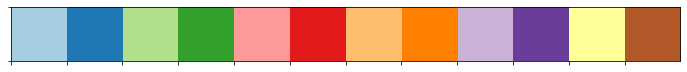

In [102]:
colors = sns.color_palette("Paired")
sns.palplot(colors)
color_codes = colors.as_hex()

In [103]:
stations.region_id.value_counts()

42     302
41      92
44      46
43      36
104     34
40      31
133     23
152     10
Name: region_id, dtype: int64

In [104]:
def assign_colors(ids):
    color_for_id = {}
    next_color_idx = 0
    colors = []
    for x in ids:
        if x not in color_for_id:
            color_for_id[x] = color_codes[next_color_idx]
            next_color_idx += 1
        colors.append(color_for_id[x])
    return colors

In [105]:
stations['marker_color'] = assign_colors(stations.region_id)

In [106]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

display(m)

In [107]:
from sklearn.cluster import KMeans

In [108]:
km = KMeans(n_clusters=8)

In [109]:
stations['kmeans(8)_cluster'] = km.fit_predict(stations[["lat", "lon"]])

stations['kmeans(8)_cluster'].value_counts()

0    174
6    110
3     76
1     72
5     61
7     36
4     29
2     16
Name: kmeans(8)_cluster, dtype: int64

In [110]:
stations['marker_color'] = assign_colors(stations['kmeans(8)_cluster'])

In [111]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

for cluster_center in km.cluster_centers_:
    folium.CircleMarker(
        location=cluster_center,
        radius=10,
        fill="red"
    ).add_to(m)
    
display(m)

In [112]:
before_noon_rides = rides.query('start_hour < 12')

In [113]:
traffic_data = pd.merge(
    before_noon_rides.groupby('Start station number').size().to_frame("num_morning_departures"),
    before_noon_rides.groupby('End station number').size().to_frame("num_morning_arrivals"),
    left_index=True, right_index=True
)
stations_with_traffic = pd.merge(
    stations,
    traffic_data,
    left_on="short_name", right_index=True,
    how='inner'
)
stations_with_traffic.head()

,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id,marker_color,kmeans(8)_cluster,num_morning_departures,num_morning_arrivals
0,19,False,[{'id': '5029b3a1-a049-46f9-a13c-c7ffef2bb88c'...,False,08249be7-1f3f-11e7-bf6b-3863bb334450,True,38.902221,-77.059219,Georgetown Harbor / 30th St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31215,72,#a6cee3,0,366,1309
1,23,False,[{'id': '6944e559-dc16-4a55-9125-e2c3256e294e'...,False,0824aa39-1f3f-11e7-bf6b-3863bb334450,True,38.900283,-77.029822,13th St & New York Ave NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31227,91,#a6cee3,0,399,1803
2,35,False,[{'id': '2a0089f1-ce95-4633-9471-61b0f70b7c08'...,False,0824c80d-1f3f-11e7-bf6b-3863bb334450,True,38.902061,-77.038322,17th & K St NW / Farragut Square,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31233,106,#a6cee3,0,603,2248
3,14,False,NaN,False,082469cc-1f3f-11e7-bf6b-3863bb334450,True,38.858971,-77.053230,Eads St & 15th St S,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31000,1,#1f78b4,5,138,56
4,11,False,NaN,False,08246b69-1f3f-11e7-bf6b-3863bb334450,True,38.857250,-77.053320,18th St & S Eads St,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31001,2,#1f78b4,5,130,109


In [114]:
stations_with_traffic.groupby('region_id').num_morning_departures.mean()

region_id
40     157.064516
41     207.597701
42     762.173554
43      27.470588
44      82.476190
104     22.500000
Name: num_morning_departures, dtype: float64

In [119]:
len(stations)

574

In [115]:
len(stations_with_traffic)

439

In [116]:
len(traffic_data)

443

In [117]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations_with_traffic.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

for cluster_center in km.cluster_centers_:
    folium.CircleMarker(
        location=cluster_center,
        radius=10,
        fill="red"
    ).add_to(m)
    
display(m)

In [118]:
stations_with_traffic.groupby('kmeans(8)_cluster')[['num_morning_departures', 'num_morning_arrivals']].mean().style.bar()

,num_morning_departures,num_morning_arrivals
kmeans(8)_cluster,,
0,929.212,1058.85
1,120.371,79
2,23.8182,23.0909
3,227.343,184.443
4,24,17.9
5,162.981,158.811
6,615.829,429.214
7,27.4706,28.1176
